In [1]:
import os
from dotenv import load_dotenv
import subprocess
import warnings
warnings.filterwarnings("ignore")
from pydantic import BaseModel, Field
from langchain.tools import BaseTool, StructuredTool, tool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor,create_react_agent,create_openai_functions_agent # To load simple ReAct agent. Reason an act
from langchain import hub


In [2]:
# Define API key for OPenAI
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")


### Tool 1: RDF_calc_tool

This tool reads a LAMMPS data file and a trajectory in the DCD format and uses the MDAnalaysos to calculate the RDF

In [3]:
## Define class for description of inputs in structured tool 
class calc_rdf_Inputs(BaseModel):
    data_file: str = Field(description="LAMMPS data file")
    dcd_file: str = Field(description="LAMMPS trajectory file in DCD format")
    names: list = Field(description="Names of the atoms to calculate RDF")
    selections: list = Field(description="Selections of the atoms to calculate RDF")
    output_file: str = Field(description="Output file name for the RDF plot")


## Function to obtain the RDF from an NVT simulation 
def get_rdf(data_file, dcd_file, names,selections, output_file):
## Import MDAnalysis to analyze trajectory
    import MDAnalysis
    from MDAnalysis.analysis.rdf import InterRDF
    # Define Universe
    u = MDAnalysis.Universe(data_file, dcd_file, format="LAMMPS")

    ## Define selections
    selection1 = u.select_atoms(selections[0])
    selection2 = u.select_atoms(selections[1])

    ## Calculate RDF
    rdf = InterRDF(selection1, selection2, range=(0.2, 10.0), nbins=50,norm='rdf')
    rdf.run()
    #save to file using numpy
    import numpy as np
    np.savetxt('rdf.dat', np.column_stack((rdf.bins, rdf.rdf)), header='r (Angstrom) g(r)', comments='#')

    ## Plot RDF
    import matplotlib.pyplot as plt
    plt.plot(rdf.bins, rdf.rdf, label=f'{names[0]}-{names[1]}')
    plt.xlabel('r ($\AA$)')
    plt.ylabel('g(r)')
    plt.legend()
    plt.savefig(output_file)
    plt.show()

    return

# ## test 
# data_file = 'system.data'
# dcd_file = 'trajectory.dcd'
# names = ['O','O']
# selections = ['type 1','type 1']
# output_file = 'rdf.png'

# os.makedirs('tool_1', exist_ok=True)
# os.chdir('tool_1')
# get_rdf(data_file, dcd_file, names,selections, output_file)
# os.chdir('..')

## Define Structured Tool
calc_rdf_tool = StructuredTool.from_function(
    func=get_rdf, # Function to be used
    name="calc_rdf_tool", # Function to be used
    description="Calculate RDF from LAMMPS trajectory using the data file, trajectory file, names of the atoms, selections of the atoms, and output file name", # Description of the function
    args_schema=calc_rdf_Inputs, # Schema of the inputs defined in class
    return_direct=False, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )






> Entering new AgentExecutor chain...

Invoking: `calc_rdf_tool` with `{'data_file': 'system_nvt_equil.data', 'dcd_file': 'trajectory.dcd', 'names': ['O', 'O'], 'selections': ['type 1', 'type 1'], 'output_file': 'rdf.png'}`




/afs/crc.nd.edu/user/o/omendibl/.conda/envs/dynamate/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/afs/crc.nd.edu/user/o/omendibl/.conda/envs/dynamate/lib/python3.10/site-packages/MDAnalysis/analysis/rdf.py:359: DeprecationWarning: The `bins` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.bins` instead
  warnings.warn(wmsg, DeprecationWarning)
/afs/crc.nd.edu/user/o/omendibl/.conda/envs/dynamate/lib/python3.10/site-packages/MDAnalysis/analysis/rdf.py:369: DeprecationWarning: The `rdf` attribute was deprecated in MDAnalysis 2.0.0 

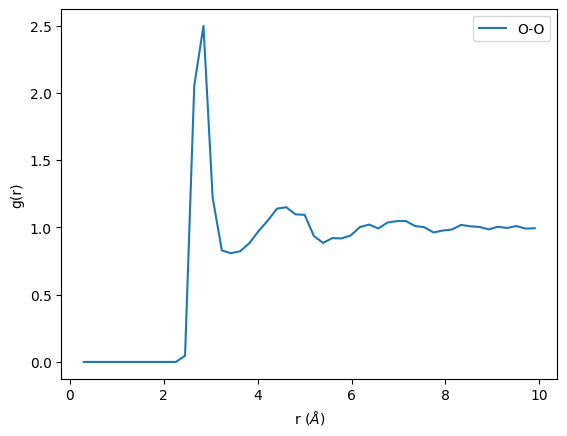

NoneThe RDF calculation has been successfully completed, and the output file is named 'rdf.png'. If you need any further assistance or analysis, feel free to ask!

> Finished chain.
The RDF calculation has been successfully completed, and the output file is named 'rdf.png'. If you need any further assistance or analysis, feel free to ask!


In [4]:
## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [calc_rdf_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def mosdef_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']

## Define test prompt 
test_prompt_1 = "Calculate the RDF from a LAMMPS trajectory using the data file 'system_nvt_equil.data', \
    trajectory file 'trajectory.dcd', names of the atoms 'O' and 'O',\
    selections of the atoms 'type 1' and 'type 1', and output file name 'rdf.png'."

# Create and move to tool_1 directory
os.makedirs("tool_1", exist_ok=True)
os.chdir("tool_1")
print(mosdef_response(test_prompt_1))
os.chdir("..")

## Tool 2: Ensenble_average_tool
This tool computes the ensemble average of an converged property from a LAMMPS log file. It does this by  extracting the trajectory from a LAMMPS log file and then determining convergence based on the change of the cumulative running average across the steps. The criteria for convergence is the following, when the cumulative running average does not change than 0.1% between a specified window of 50 steps, the property is considered convereged. Tolerance for convergence and the window are parameters of the tool. Once convergence is identified, simulation steps before convergence are discarded and an ensemble average is computed from the remaining steps. The tool also by default makes a figure of the trajectory of interest. If convergece is not detected, the tool will return a False statement. If converge is detected, it will return the ensemble average along with an loose estimate for the uncertanty by block averaging the remaining trajectroy. Inside the tool_2 directory there are two log files         

In [5]:
## Define class for description of inputs in structured tool 
class ensemble_average_inputs(BaseModel):
    filename: str = Field(description="Name of LAMMPS log file")
    property: str = Field(property="Property of interest to compute ensemble average")
    tolerance: float = Field(description="Tolerance for convergence in % of change")
    window: int = Field(description="Window to check for change in cumulative running integral", default=50)
    save: bool = Field(description="Wether or not to plot the trajectory of interest", default=True)


def ensemble_average(filename:str, property:str, tolerance:float = 0.1, window:int = 50, save:bool = True):
    """
    Compute ensemble average of a property from a LAMMPS log file by checking for converge and the plotting the trajectory
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    
    def parse_lammps_log(log_filename:str):
        """
        Parses the LAMMPS log file and extracts data from a Verlet run.
    
        Parameters:
        log_filename (str): Path to the LAMMPS log file.
    
        Returns:
        data (dict): A dictionary where keys are column headers and values are lists of data points.
        """
        data = {}
        in_run = False
        headers = []
        with open(log_filename, 'r') as file:
            for line in file:
                line = line.strip()
    
                # Identify the start of the Verlet run output
                if line.startswith('Step'):
                    headers = line.split()
                    # Initialize data lists for each header
                    for header in headers:
                        data[header] = []
                    in_run = True
                    continue
    
                # If we're inside a run, collect the data
                elif in_run:
                    if not line or line.startswith('Loop time'):
                        # End of data section
                        in_run = False
                        continue
                    else:
                        values = line.split()
                        # Ensure the line has the correct number of values
                        if len(values) == len(headers):
                            for i, value in enumerate(values):
                                # Convert numeric values to float
                                try:
                                    data[headers[i]].append(float(value))
                                except ValueError:
                                    data[headers[i]].append(value)
                        else:
                            # Data line doesn't match header length; end of this data section
                            in_run = False
        return data
    
    converged = False
    
    # Load the log file
    data = parse_lammps_log(filename)
    header = list(data.keys())
    
    # Check if the property is in the headers
    if property in header:
        # Get data from log file
        property_data = data[property]
    else:
        # Handle the error
        raise KeyError(f"The property '{property}' is not found in the log file headers.")
    
    # get data from log file
    timestep_data = data['Step']

    # convert extracted property data into df
    property_df = pd.DataFrame(data=property_data)  

    # calculate cumulative running average
    cum_running_average_df = property_df.expanding().mean()  
    
    # Turn CRA into flat np.array
    cum_running_average = cum_running_average_df.to_numpy().flatten()  
    
    # Looping parameters
    change_of_CRA = []  # log of percent changes not meeting tolerance
    time_change_of_CRA = []  # log of time indexes where tolerance is not met
    time_change_index = -1  # Counter to keep track of when cutoff is done for graphing

    for ii in np.arange(window, len(cum_running_average_df), window):

        point_1 = cum_running_average[ii - window]
        point_2 = cum_running_average[ii]
        percent_change = np.abs(point_1 - point_2) / np.abs(point_2) * 100

        if percent_change >= tolerance:
            time_change_index = time_change_index + 1
            change_of_CRA = np.append(change_of_CRA, percent_change)
            time_change_of_CRA = np.append(time_change_of_CRA, timestep_data[ii])
        else:
            index_of_tolerance_met = ii
            converged = True
            break

    # Graphing
    if save:
        rolling_running_average_df = property_df.rolling(window).mean()
        rolling_running_average = rolling_running_average_df.to_numpy().flatten()
        
        fig, ax1 = plt.subplots()

        ax1.set_xlabel('Step')
        ax1.set_ylabel(property)
        ax1.plot(timestep_data, property_data, label=property)
        ax1.plot(timestep_data, cum_running_average, label='Cumulative Running Average')
        ax1.plot(timestep_data, rolling_running_average, label='Rolling Running Average', color='black')

        plt.legend(loc="lower right", bbox_to_anchor=(0.4, -0.3))

        ax2 = ax1.twinx()  # instantiate cum_running_average second axes that shares the same x-axis
        ax2.set_ylabel('% Change of Cumulative Running Average')  # we already handled the x-label with ax1
        ax2.plot(time_change_of_CRA, change_of_CRA, label='% Change of Cumulative Running Average', color='tab:green')
        
        if converged is True:
            ax2.plot([time_change_of_CRA[time_change_index], time_change_of_CRA[time_change_index]],
                     [np.min(change_of_CRA), np.max(change_of_CRA)],
                     color='tab:red', label='Cutoff')

        fig.tight_layout()  # otherwise the right y-label is slightly
        plt.legend(loc="lower left", bbox_to_anchor=(0.4, -0.3))
        
        if save is not False:
            plt.savefig("./" + property + "_trajectory.png")

    # extract Production data
    if converged is True:
        equilibrium_property_data = property_data[index_of_tolerance_met:]  
        equilibrium_time_data = timestep_data[index_of_tolerance_met:]
        equilibrium_production_data = np.vstack((equilibrium_time_data, equilibrium_property_data))
        print(np.mean(equilibrium_production_data[1]))
        return np.mean(equilibrium_production_data[1])
        
    elif converged is False:
        return converged

## Define Structured Tool
ensemble_average_tool = StructuredTool.from_function(
    func=ensemble_average, # Function to be used
    name="Ensemble_Average_tool", # Function to be used
    description="Compute ensemble average of a property by checking if property converged and plotting the trajectroy. Inputs are [filename:str (Name of log file), property:str (property of interest), tolerance:float (tolerance of convergance in %), window:int (window to check for change in convergance), save:bool (save the plotted trajectory)", # Description of the tool"
    args_schema=ensemble_average_inputs, # Schema of the inputs defined in class
    return_direct=True, # Return the output directly
    handle_error=True, # Handle errors
    # Use dictionary as input
    )

In [6]:
## Define LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# Define list of tools the LLM is going to use 
tools = [ensemble_average_tool]

## Propomt for openai function
prompt = hub.pull("hwchase17/openai-functions-agent")
#print(prompt)

# Create OpenAI functions agent
agent = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# ## Create Agent executor
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True,handle_parsing_errors=True)

def ensemble_average_response(input_text:str):
    return agent_executor.invoke({"input": input_text})['output']



> Entering new AgentExecutor chain...

Invoking: `Ensemble_Average_tool` with `{'filename': 'log.lammps_test', 'property': 'Density', 'tolerance': 0.1, 'window': 50, 'save': True}`


0.7945787568509984
0.7945787568509984


> Finished chain.
0.7945787568509984


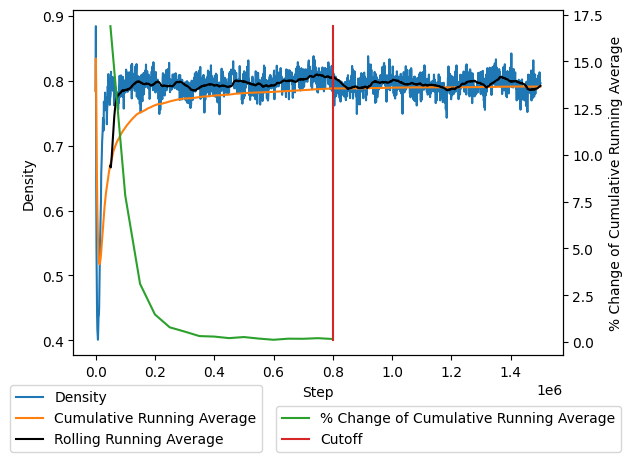

In [7]:
## Define test prompt 
test_prompt_2 = "Has the Density in the LAMMPS log file called log.lammps_test file converged if so what is the average? use a tolerance of 0.1, a window of 50 and save a plot of the trajectory"

# Create and move to tool_1 directory
os.chdir("./tool_2")
print(ensemble_average_response(test_prompt_2))
os.chdir("..")



> Entering new AgentExecutor chain...

Invoking: `Ensemble_Average_tool` with `{'filename': 'bad_log.lammps_test', 'property': 'Press', 'tolerance': 1}`


False


> Finished chain.
False


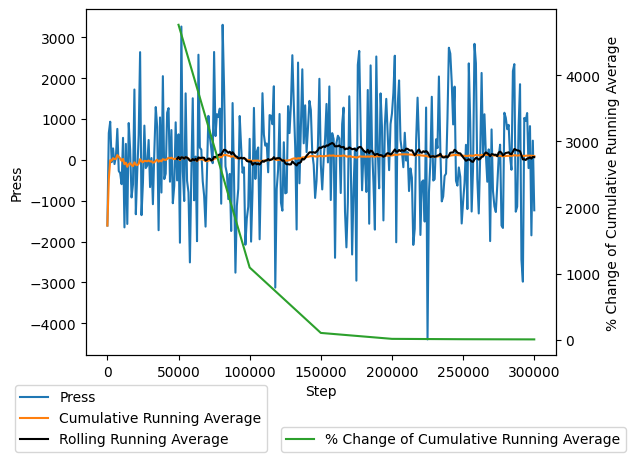

In [8]:
## Define test prompt 
test_prompt_3 = "Has Press in the LAMMPS log file called bad_log.lammps_test file converged if so what is the average?"

# Create and move to tool_1 directory
os.chdir("./tool_2")
print(ensemble_average_response(test_prompt_3))
os.chdir("..")